# CliffWalking SARSA

## 实验目标

本实验使用 `SARSA` 求解 CliffWalking，目标是展示 on-policy 学习在带有明确风险区域的环境里，为什么常常会学出更保守、更稳妥的路径。这个实验的重点不是只跑出终点，而是让读者看到风险与回报平衡如何影响策略形状。

## 为什么这里选择 SARSA

CliffWalking 是解释 `SARSA` 的经典环境之一。和 `Q-Learning` 相比，`SARSA` 学习的是当前实际执行策略下的价值，因此在带探索的训练过程中，更容易形成相对保守的行为模式。放在这个环境里，它往往会选择离悬崖稍远一些、虽然步数略多但更安全的路径。

## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不使用并行环境

原因是本实验是典型表格强化学习任务，更新对象只是一张 Q 表，没有必要引入 GPU 或并行采样。

In [1]:
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [2]:
ENV_ID = "CliffWalking-v1"
NUM_EPISODES = 30000
MAX_STEPS = 200
LEARNING_RATE = 0.1
GAMMA = 1.0
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.9998
ROLLING_WINDOW = 200
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)
num_states = env.observation_space.n
num_actions = env.action_space.n
q_table = np.zeros((num_states, num_actions), dtype=np.float32)

## 参数选择说明

- `NUM_EPISODES = 30000`：给表格方法足够训练回合，避免只学到非常粗糙的策略
- `LEARNING_RATE = 0.1`：作为表格方法的稳妥起点
- `GAMMA = 1.0`：CliffWalking 的路径代价更适合完整累计未来回报
- `EPSILON_DECAY = 0.9998`：让探索衰减更慢，避免过早固定在不稳定路径上
- `ROLLING_WINDOW = 200`：平滑训练曲线，便于观察趋势

如果训练后策略仍明显不稳，优先调整的方向通常是：

- 增加训练回合数
- 放慢 epsilon 衰减
- 微调学习率

In [3]:
def epsilon_greedy_action(q_values, state, epsilon, action_space):
    if np.random.random() < epsilon:
        return action_space.sample()
    return int(np.argmax(q_values[state]))

In [4]:
epsilon = EPSILON_START
episode_rewards = []
episode_successes = []
cliff_falls = []
epsilons = []

for episode in tqdm(range(NUM_EPISODES), desc="SARSA episodes"):
    state, info = env.reset(seed=SEED + episode)
    action = epsilon_greedy_action(q_table, state, epsilon, env.action_space)
    total_reward = 0.0
    fell = 0

    for step in range(MAX_STEPS):
        next_state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        if reward <= -100:
            fell = 1

        next_action = epsilon_greedy_action(q_table, next_state, epsilon, env.action_space)
        td_target = reward + GAMMA * q_table[next_state, next_action] * (1 - int(terminated or truncated))
        td_error = td_target - q_table[state, action]
        q_table[state, action] += LEARNING_RATE * td_error

        state = next_state
        action = next_action

        if terminated or truncated:
            episode_success = int(terminated)
            break
    else:
        episode_success = 0

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    episode_rewards.append(total_reward)
    episode_successes.append(episode_success)
    cliff_falls.append(fell)
    epsilons.append(epsilon)

env.close()

SARSA episodes:   0%|          | 0/30000 [00:00<?, ?it/s]

In [5]:
reward_series = pd.Series(episode_rewards)
success_series = pd.Series(episode_successes)
fall_series = pd.Series(cliff_falls)
epsilon_series = pd.Series(epsilons)

rolling_reward = reward_series.rolling(ROLLING_WINDOW).mean()
rolling_success = success_series.rolling(ROLLING_WINDOW).mean()
rolling_fall = fall_series.rolling(ROLLING_WINDOW).mean()

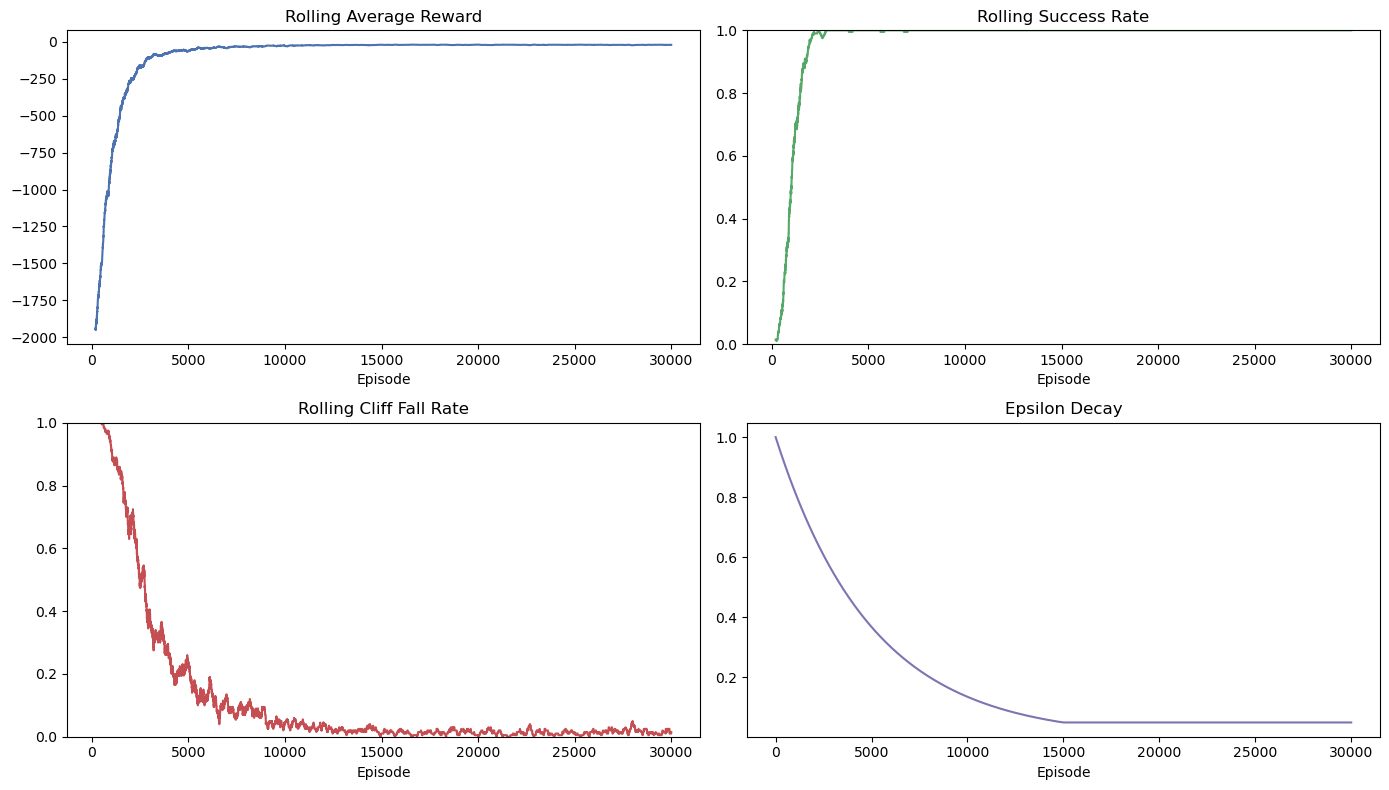

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(rolling_reward, color="#4c72b0")
axes[0, 0].set_title("Rolling Average Reward")
axes[0, 0].set_xlabel("Episode")

axes[0, 1].plot(rolling_success, color="#55a868")
axes[0, 1].set_title("Rolling Success Rate")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylim(0, 1)

axes[1, 0].plot(rolling_fall, color="#c44e52")
axes[1, 0].set_title("Rolling Cliff Fall Rate")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylim(0, 1)

axes[1, 1].plot(epsilon_series, color="#8172b3")
axes[1, 1].set_title("Epsilon Decay")
axes[1, 1].set_xlabel("Episode")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "sarsa_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

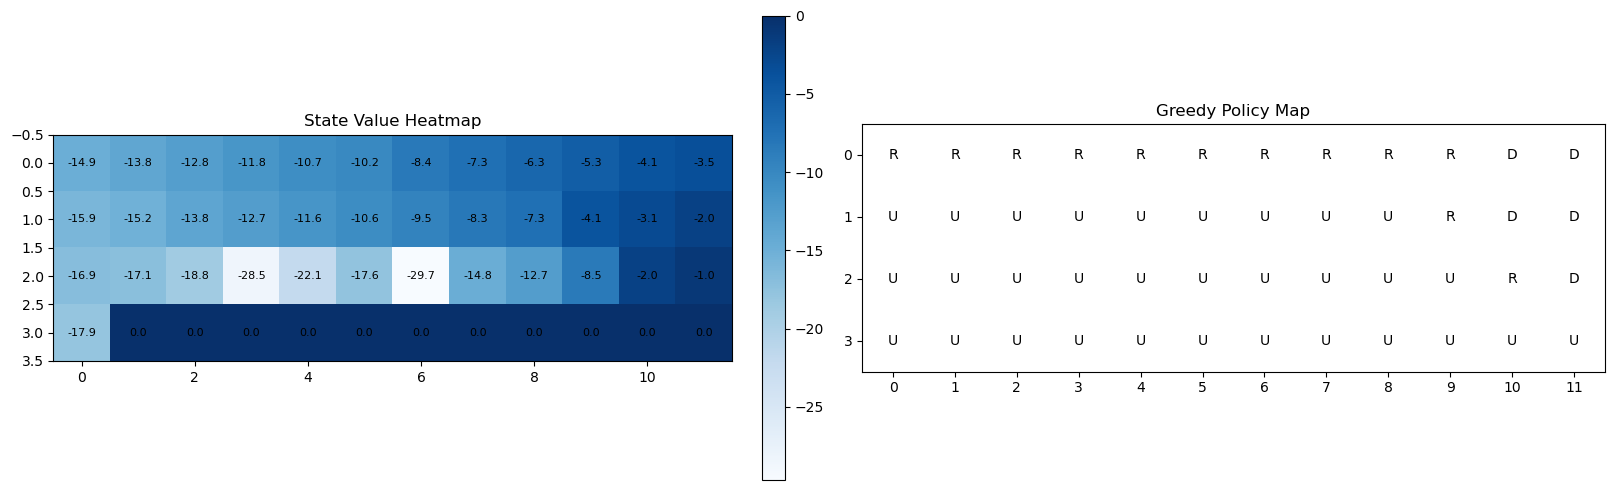

In [7]:
action_symbols = np.array(["U", "R", "D", "L"])
best_actions = action_symbols[np.argmax(q_table, axis=1)].reshape(4, 12)
state_values = np.max(q_table, axis=1).reshape(4, 12)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(state_values, cmap="Blues")
axes[0].set_title("State Value Heatmap")
for i in range(4):
    for j in range(12):
        axes[0].text(j, i, f"{state_values[i, j]:.1f}", ha="center", va="center", color="black", fontsize=8)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].imshow(np.zeros((4, 12)), cmap="Greys", vmin=0, vmax=1)
axes[1].set_title("Greedy Policy Map")
for i in range(4):
    for j in range(12):
        axes[1].text(j, i, best_actions[i, j], ha="center", va="center", color="black", fontsize=10)
axes[1].set_xticks(range(12))
axes[1].set_yticks(range(4))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "sarsa_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
metrics = pd.DataFrame(
    {
        "metric": [
            "overall_success_rate",
            "average_reward",
            "cliff_fall_rate",
            "final_epsilon",
        ],
        "value": [
            float(np.mean(episode_successes)),
            float(np.mean(episode_rewards)),
            float(np.mean(cliff_falls)),
            float(epsilon),
        ],
    }
)
metrics

,metric,value
0,overall_success_rate,0.967700
1,average_reward,-89.048467
2,cliff_fall_rate,0.118933
3,final_epsilon,0.050000


In [9]:
metrics.to_csv(RESULTS_DIR / "sarsa_metrics.csv", index=False)
pd.DataFrame(q_table).to_csv(RESULTS_DIR / "sarsa_q_table.csv", index=False)

print(f"Overall success rate: {np.mean(episode_successes):.4f}")
print(f"Average reward: {np.mean(episode_rewards):.2f}")
print(f"Cliff fall rate: {np.mean(cliff_falls):.4f}")
print(f"Final epsilon: {epsilon:.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")

Overall success rate: 0.9677
Average reward: -89.05
Cliff fall rate: 0.1189
Final epsilon: 0.0500
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/03-cliffwalking-sarsa/results


## 结果解读

这个实验最重要的是看策略形状和风险偏好，而不仅仅是是否能到终点。重点观察：

- 平均回报是否逐步改善
- 掉崖率是否逐步下降
- 最终策略是否沿着离悬崖稍远的位置前进

如果这些现象都成立，就说明 `SARSA` 正在学一条更稳妥、风险更低的路线。这正是它在 CliffWalking 里最典型、也最有教学价值的地方。